# wflow SBM Layered Soil Model vs VAMPS (Brooks-Corey, matched parameters)

This notebook implements the **vertical soil water component** of the
[wflow.jl SBM model](https://github.com/Deltares/Wflow.jl) (Simple Bucket Model)
in Python, and compares it to VAMPS which solves the full **Richards equation**.

Both models use **identical Brooks-Corey hydraulic parameters** from `fiji_bandC.inp`
and are driven by the same Fiji tropical forest forcing.

This is a short very incomplete test done in a couple of hours. The results below are speecific to this 
forcing and soil type (thick tropical clay) and results will be differen for different soild types
and climatic forcing. Als I have use a free drainage soil column, no groundwater level forcing.

Spoiler, given the fact that the models use a very different approuch to solving the soil
water balance results in very similar in this case.

## Conceptual differences

| | wflow SBM | VAMPS Richards |
|---|---|---|
| **Approach** | Conceptual bucket model | Physical PDE (Richards eq.) |
| **Hydraulics** | Brooks-Corey power law | Brooks-Corey power law (method 6) |
| **Layers** | 3 user-defined buckets | 77 thin numerical layers (2 cm each) |
| **Flow** | Unit-gradient (gravity only) | Pressure-head gradient (gravity + capillary) |
| **Water table** | Pseudo-depth from storage | Derived from h profile |
| **Root uptake** | Feddes α(h), Brooks-Corey h(θ) | Feddes α(h), Richards h directly (`swsink=1`) |
| **Parameters** | θ_s, θ_r, λ, h_b, K_sat (BC) | θ_s, θ_r, λ, h_b, K_sat (BC) |

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Add repo root to path
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), ''))
sys.path.insert(0, '..')
from vampspy import Model

FIJI_DIR = os.path.join('..', 'examples', 'fiji')


## 1. SBM core functions

Translated directly from [`Wflow/src/soil/soil_process.jl`](https://github.com/Deltares/Wflow.jl/blob/master/Wflow/src/soil/soil_process.jl)
and [`Wflow/src/utils.jl`](https://github.com/Deltares/Wflow.jl/blob/master/Wflow/src/utils.jl).


In [2]:
# ---------------------------------------------------------------------------
# SBM core functions — translated from wflow.jl
# ---------------------------------------------------------------------------

def unsatzone_flow_layer(usd, kv_z, l_sat, c):
    """Transfer water from an unsaturated layer downward.

    Assumes unit head gradient (gravity drainage only).

    Parameters
    ----------
    usd   : current unsaturated storage in layer [mm]
    kv_z  : vertical K_sat at the bottom of the layer [mm timestep⁻¹]
    l_sat : layer storage at saturation = thickness*(θ_s - θ_r) [mm]
    c     : Brooks-Corey power coefficient = 3 + 2/λ  [-]

    Returns
    -------
    usd_new : updated storage [mm]
    flux    : water transferred downward [mm timestep⁻¹]
    """
    if usd <= 0.0:
        return 0.0, 0.0

    # 1. Transfer water that already exceeds layer capacity (instant)
    st_sat = max(0.0, usd - l_sat)
    st = kv_z * min((usd / l_sat) ** c, 1.0)
    sum_ast = min(st, st_sat)
    usd -= sum_ast

    # 2. Sub-iterate to avoid overshooting (max 0.2 mm per sub-step)
    remainder = min(st - sum_ast, usd)
    its = max(1, int(np.ceil(remainder / 0.2)))
    for _ in range(its):
        st_i = (kv_z / its) * min((usd / l_sat) ** c, 1.0)
        ast = min(st_i, usd)
        usd -= ast
        sum_ast += ast

    return usd, sum_ast


def vwc_brooks_corey(h, hb, theta_s, theta_r, c):
    """Volumetric water content from Brooks-Corey retention curve."""
    if h < hb:
        par_lambda = 2.0 / (c - 3.0)
        return (theta_s - theta_r) * (hb / h) ** par_lambda + theta_r
    return theta_s


def head_brooks_corey(vwc, theta_s, theta_r, c, hb):
    """Soil water pressure head from Brooks-Corey retention curve."""
    par_lambda = 2.0 / (c - 3.0)
    if par_lambda > 0:
        return hb / ((vwc / (theta_s - theta_r)) ** (1.0 / par_lambda))
    return hb


def rwu_reduction_feddes(h, h1, h2, h3, h4, alpha_h1=0.0):
    """Root water uptake reduction factor (Feddes et al. 1978).

    h1 > h2 > h3 > h4 (all ≤ 0, in cm)
    Returns α ∈ [0, 1].
    """
    if h < h4:
        return 0.0
    if h < h3:
        return (h - h4) / (h3 - h4)
    if alpha_h1 == 0.0:
        if h < h2:
            return 1.0
        if h < h1:
            return (h1 - h) / (h1 - h2)
        return 0.0
    return 1.0


def scurve(x, a, b, c):
    """Sigmoid curve used for wet-root fraction."""
    return 1.0 / (b + np.exp(-c * (x - a)))


def set_layerthickness(zi, cum_depth, act_thick):
    """Compute unsaturated thickness of each layer given water table depth zi."""
    out = np.full_like(act_thick, np.nan)
    for i, (z0, z1, dz) in enumerate(zip(cum_depth[:-1], cum_depth[1:], act_thick)):
        if zi > z1:
            out[i] = dz          # fully unsaturated
        elif zi - z0 > 0.0:
            out[i] = zi - z0     # partially unsaturated
        # else: fully saturated → remains NaN
    return out


## 2. Soil parameters (matched to fiji_bandC.inp)

Three SBM layers are mapped to the three hydraulic units in the Fiji soil profile.
Both models use the Brooks-Corey retention parameters directly from `fiji_bandC.inp`
(VAMPS `method = 6`).  The exponent `c = 3 + 2/λ` appears in the SBM unit-gradient
drainage function K(Sₑ) = K_sat × Sₑ^c.

| Layer | Depth (mm) | K_sat (mm d⁻¹) | θ_s | θ_r | λ | c = 3+2/λ | h_b (cm) |
|-------|-----------|----------------|-----|-----|---|-----------|---------|
| Top   | 0–280     | 18 000         | 0.60 | 0.08 | 0.098 | 23.4 | −16.4 |
| Mid   | 280–720   | 3 800          | 0.64 | 0.08 | 0.094 | 24.3 | −23.8 |
| Deep  | 720–1540  | 30             | 0.60 | 0.08 | 0.094 | 24.3 | −23.8 |

In [3]:
# ---------------------------------------------------------------------------
# Soil parameters -- matched exactly to fiji_bandC.inp (Brooks-Corey)
# Units: mm, mm d-1 for fluxes/distances; cm for pressure heads (Feddes)
# ---------------------------------------------------------------------------

LAYER_BOUNDS = np.array([0.0, 280.0, 720.0, 1540.0])   # mm
ACT_THICK    = np.diff(LAYER_BOUNDS)                     # [280, 440, 820] mm
CUM_DEPTH    = LAYER_BOUNDS
NLAYERS      = len(ACT_THICK)
SOILTHICKNESS = LAYER_BOUNDS[-1]                         # 1540 mm

# --- Hydraulic parameters -- directly from fiji_bandC.inp ---
#
#   VAMPS conversion:  lambda = n_vg - 1,   hb = -1/alpha_vg  [cm]
#   ksat in VAMPS: cm d-1; converted to mm d-1 (x10) for SBM.
#
#                       st_0            st_1           st_2
THETA_S   = np.array([0.60,            0.64,          0.60  ])
THETA_R   = np.array([0.08,            0.08,          0.08  ])
LAMBDA_BC = np.array([0.098,           0.094,         0.094 ])  # pore-size index
C_BC      = 3.0 + 2.0 / LAMBDA_BC                               # [23.4, 24.3, 24.3]
HB_LAYER  = np.array([-16.4,          -23.8,         -23.8 ])   # air-entry pressure [cm]
# Ksat [mm d-1] -- VAMPS values (1800, 380, 3 cm/d) x 10
KV_LAYER  = np.array([1800.0, 380.0, 3.0]) * 10.0               # [18000, 3800, 30] mm/d
KVFRAC    = np.ones(NLAYERS)

SOILWATERCAPACITY = (THETA_S - THETA_R) * ACT_THICK
MAXLEAKAGE = KV_LAYER[-1]    # 30 mm d-1

# --- Feddes root water uptake thresholds [cm] (from fiji_bandC.inp) ---
H1 = -5.0; H2 = -50.0; H3_HIGH = -800.0; H3_LOW = -1000.0
H4 = -12000.0; ALPHA_H1 = 0.0

ROOTINGDEPTH = 1200.0    # mm
INFILTCAPSOIL = 200.0    # mm d-1
INFILTCAPPATH = 0.0; PATHFRAC = 0.0

# Field capacity at h = -100 cm
def field_capacity_bc(h_fc=-100.0):
    fc = (THETA_S - THETA_R) * (HB_LAYER / h_fc) ** LAMBDA_BC + THETA_R
    return np.minimum(fc, THETA_S)

THETA_FC = field_capacity_bc()
THETA_DRAINABLE = np.maximum(THETA_S - THETA_FC, 0.02)

print('Layer thicknesses (mm):           ', ACT_THICK)
print('Brooks-Corey lambda:              ', LAMBDA_BC)
print('Brooks-Corey c (= 3+2/lambda):    ', C_BC.round(2))
print('Air-entry pressure hb (cm):       ', HB_LAYER)
print('K_sat per layer (mm/d):           ', KV_LAYER)
print(f'Bottom drainage (mm/d):            {MAXLEAKAGE:.1f}')
print('Soil water capacity per layer (mm):', SOILWATERCAPACITY.round(1))
print('Field capacity theta_fc:           ', THETA_FC.round(3))
print('Drainable porosity:                ', THETA_DRAINABLE.round(3))


Layer thicknesses (mm):            [280. 440. 820.]
Brooks-Corey lambda:               [0.098 0.094 0.094]
Brooks-Corey c (= 3+2/lambda):     [23.41 24.28 24.28]
Air-entry pressure hb (cm):        [-16.4 -23.8 -23.8]
K_sat per layer (mm/d):            [18000.  3800.    30.]
Bottom drainage (mm/d):            30.0
Soil water capacity per layer (mm): [145.6 246.4 426.4]
Field capacity theta_fc:            [0.516 0.569 0.534]
Drainable porosity:                 [0.084 0.071 0.066]


## 3. Initial conditions

Derived from the `theta_initial` profile in `fiji.inp`.

In [4]:
# ---------------------------------------------------------------------------
# Initial conditions from fiji.inp theta_initial profile
# ---------------------------------------------------------------------------

theta_initial_vamps = np.array([
    0.200000, 0.210000, 0.220000, 0.220000, 0.265000,
    0.300000, 0.350000, 0.375817, 0.377095, 0.383497,
    0.380000, 0.380000, 0.380000, 0.443651, 0.400000,
    0.400000, 0.400000, 0.400000, 0.410000, 0.420000,
    0.430000, 0.440000, 0.470000, 0.470000, 0.470000,
    0.470000, 0.470000, 0.544194, 0.470000, 0.470000,
    0.460000, 0.460000, 0.460000, 0.460000, 0.582024,
    0.460000, 0.460000, 0.460000, 0.460000, 0.460000,
    0.460000, 0.514537, 0.506907, 0.506545, 0.505096,
    0.504733, 0.495707, 0.489597, 0.492829, 0.501117,
    0.505820, 0.499311, 0.497508, 0.497508, 0.497508,
    0.497508, 0.497508, 0.497508, 0.497508, 0.497508,
    0.497508, 0.497508, 0.497508, 0.497508, 0.497508,
    0.497508, 0.497508, 0.497508, 0.497508, 0.497508,
    0.497508, 0.497508, 0.497508, 0.497508, 0.497508,
    0.497508, 0.497508,
])
N_VAMPS = len(theta_initial_vamps)   # 77
DZ_VAMPS = 2.0  # cm = 20 mm per VAMPS layer
DZ_VAMPS_MM = DZ_VAMPS * 10.0       # 20 mm

# Aggregate to 3 SBM layers (by matching layer boundaries)
# Layer 1: VAMPS layers 0-13  (0 – 280 mm)
# Layer 2: VAMPS layers 14-35 (280 – 720 mm)
# Layer 3: VAMPS layers 36-76 (720 – 1540 mm)
idx = [0, 14, 36, 77]
theta_ini_sbm = np.array([
    theta_initial_vamps[idx[i]:idx[i+1]].mean() for i in range(NLAYERS)
])
print("Initial θ per SBM layer:", theta_ini_sbm.round(4))

# Initial unsaturated storage per layer — derived directly from the VAMPS
# theta_initial profile, averaged per SBM layer.  No water-table cap is
# applied: the VAMPS model itself runs with gwlevel=1.0 m (free-drainage
# bottom BC) and the theta_initial values already encode the moisture state.
# Applying a zi-cap would under-initialize the deep layer relative to VAMPS.
ustorelayerdepth_ini = (theta_ini_sbm - THETA_R) * ACT_THICK
print("ustorelayerdepth_ini (mm):", ustorelayerdepth_ini.round(1))
print("Total initial soil water (SBM,   mm):",
      (ustorelayerdepth_ini.sum() + THETA_R.mean() * SOILTHICKNESS).round(1))
print("Total initial soil water (VAMPS, mm):",
      (theta_initial_vamps * DZ_VAMPS_MM).sum().round(1))


Initial θ per SBM layer: [0.3204 0.4553 0.4941]
ustorelayerdepth_ini (mm): [ 67.3 165.1 339.6]
Total initial soil water (SBM,   mm): 695.2
Total initial soil water (VAMPS, mm): 695.2


## 4. Forcing data

Load Fiji climate series and compute potential ET via Penman–Monteith.

In [5]:
# ---------------------------------------------------------------------------
# Load forcing: 61 base days tiled to NSTEPS days
# ---------------------------------------------------------------------------
BASE_STEPS = 61   # length of original forcing record
NSTEPS     = 180  # simulation length

def load_prn(fname):
    return np.loadtxt(os.path.join(FIJI_DIR, fname))[:BASE_STEPS, 1]

precip_cm  = load_prn('precip.prn')   # cm d⁻¹
rnet_W     = load_prn('rnet.prn')     # W m⁻²
temp_C     = load_prn('newt.prn')     # °C
rh         = load_prn('rh.prn')       # 0–1 relative humidity
wind       = load_prn('wind.prn')     # m s⁻¹

precip_mm = precip_cm * 10.0          # → mm d⁻¹

# ---- Tile all forcing arrays to NSTEPS ----
def tile_to(arr, n):
    reps = -(-n // len(arr))   # ceiling division
    return np.tile(arr, reps)[:n]

precip_mm = tile_to(precip_mm, NSTEPS)
rnet_W    = tile_to(rnet_W,    NSTEPS)
temp_C    = tile_to(temp_C,    NSTEPS)
rh        = tile_to(rh,        NSTEPS)
wind      = tile_to(wind,      NSTEPS)

# ---------------------------------------------------------------------------
# Penman-Monteith ET  [mm d⁻¹]
# Using same ra / rs as fiji.inp [canopy] section (canopy transpiration method 2)
#   ra = 7 s m⁻¹,  rs = 60 s m⁻¹
#
# Consistent-units formulation (all rates in d⁻¹, energy in MJ m⁻² d⁻¹):
#   ET = [Δ·Rn + ρa·cp·VPD/ra_d] / [λ·(Δ + γ·(1+rs/ra))]
# where ra_d = ra_s / 86400  [d m⁻¹]
# ---------------------------------------------------------------------------
RA_S, RS_S = 7.0, 60.0          # s m⁻¹
lam_MJ     = 2.45               # MJ kg⁻¹ latent heat
gamma_kPa  = 0.067              # kPa °C⁻¹ psychrometric constant
rho_a_cp   = 1.2 * 1.013e-3    # MJ m⁻³ °C⁻¹  (ρa·cp)

esat   = 0.6108 * np.exp(17.27 * temp_C / (temp_C + 237.3))   # kPa
vpd    = esat * (1.0 - rh / 100.0)       # rh.prn is 0–100 %                                      # kPa
Delta  = 4098 * esat / (temp_C + 237.3) ** 2                   # kPa °C⁻¹
Rn_MJ  = rnet_W * 86400 / 1e6                                  # MJ m⁻² d⁻¹
ra_d   = RA_S / 86400                                           # d m⁻¹

ET_PM = np.maximum(
    (Delta * Rn_MJ + rho_a_cp * vpd / ra_d)
    / (lam_MJ * (Delta + gamma_kPa * (1.0 + RS_S / RA_S))),
    0.0,
)   # mm d⁻¹

# Partition: transpiration (canopy) / soil evaporation (bare soil fraction)
# Rnet_absorb = 0.975 (from fiji_bandC.inp [canopy]): 97.5% of Rnet absorbed
# by the canopy for transpiration; only 2.5% reaches the soil for evaporation.
RNET_ABSORB = 0.975
pot_transpiration   = ET_PM * RNET_ABSORB
pot_soilevaporation = ET_PM * (1.0 - RNET_ABSORB)

# Simple Gash interception
INTERCEPTION_FRAC = 0.147   # from fiji.inp  E_avg/R
interception     = precip_mm * INTERCEPTION_FRAC
pot_infiltration = np.maximum(precip_mm - interception, 0.0)

print("Timesteps:", NSTEPS)
print(f"Mean precip       (mm d⁻¹): {precip_mm.mean():.2f}")
print(f"Mean ET_PM        (mm d⁻¹): {ET_PM.mean():.2f}")
print(f"Mean pot_trans    (mm d⁻¹): {pot_transpiration.mean():.2f}")
print(f"Mean pot_soilevap (mm d⁻¹): {pot_soilevaporation.mean():.2f}")
print(f"Mean interception (mm d⁻¹): {interception.mean():.2f}")
print()
print("Note: VAMPS transpiration and fluxes are in cm d⁻¹;")
print("      multiply by 10 to compare with SBM mm d⁻¹ values.")


Timesteps: 180
Mean precip       (mm d⁻¹): 3.92
Mean ET_PM        (mm d⁻¹): 4.21
Mean pot_trans    (mm d⁻¹): 4.11
Mean pot_soilevap (mm d⁻¹): 0.11
Mean interception (mm d⁻¹): 0.58

Note: VAMPS transpiration and fluxes are in cm d⁻¹;
      multiply by 10 to compare with SBM mm d⁻¹ values.


## 5. SBM model run

Step-by-step time loop following `update_soil_water_flow!` in `soil.jl`.
Sequence per timestep:
1. Infiltration excess
2. Unsaturated zone flow (Brooks-Corey, layer-by-layer)
3. Soil evaporation (top layer)
4. Transpiration (Feddes, all layers + saturated store)
5. Actual infiltration & excess water check
6. Capillary flux
7. Leakage
8. Recharge → update saturated store & water table


In [6]:
# ---------------------------------------------------------------------------
# SBM time loop  — unsaturated-zone only
#
# Water table is assumed to lie below the soil profile (zi = soilthickness)
# throughout.  Transfer from the bottom of the last layer leaves the domain
# as deep percolation — directly comparable to VAMPS bottom drainage.
# Capillary rise is zero (no water table within profile).
# ---------------------------------------------------------------------------

def run_sbm(nsteps, pot_infiltration, pot_transpiration, pot_soilevaporation):
    """Run 1-D SBM vertical model for `nsteps` daily timesteps.
    
    All layers are treated as unsaturated.  Transfer from the bottom layer
    is treated as deep percolation (leaves the soil column).
    """
    # --- State: unsaturated storage per layer [mm] ---
    usd = ustorelayerdepth_ini.copy()

    # --- Unsaturated zone geometry (all layers active, constant thickness) ---
    unsat_thick = ACT_THICK.copy()   # full thickness, no saturated part

    # --- Output arrays ---
    keys = ['ustoredepth', 'deep_perc', 'infiltration', 'infiltexcess',
            'transpiration', 'soilevap', 'runoff', 'total_soilwater']
    out = {k: np.zeros(nsteps) for k in keys}
    out['usd'] = np.zeros((nsteps, NLAYERS))
    out['vwc'] = np.zeros((nsteps, NLAYERS))

    # Feddes h3 lookup
    def h3_from_tp(tp):
        if tp <= 1.0:  return H3_LOW
        if tp < 5.0:   return H3_LOW + (H3_HIGH - H3_LOW) * (tp - 1.0) / 4.0
        return H3_HIGH

    # Root fraction per layer (uniform distribution over ROOTINGDEPTH)
    rootfrac = np.zeros(NLAYERS)
    for k in range(NLAYERS):
        z0, z1 = CUM_DEPTH[k], CUM_DEPTH[k+1]
        if ROOTINGDEPTH >= z1:
            rootfrac[k] = ACT_THICK[k] / ROOTINGDEPTH
        else:
            rootfrac[k] = max(ROOTINGDEPTH - z0, 0.0) / ROOTINGDEPTH

    for step in range(nsteps):
        h3 = h3_from_tp(pot_transpiration[step])

        # --- 1. Infiltration ---
        water_in    = pot_infiltration[step]
        ustorecap   = max(0.0, (SOILWATERCAPACITY - usd).sum())
        infil       = min(min(INFILTCAPSOIL, water_in), ustorecap)
        infiltexcess = water_in - infil

        # --- 2. Unsaturated zone flow (Brooks-Corey, layer by layer) ---
        flow_in  = infil
        for m in range(NLAYERS):
            l_sat    = unsat_thick[m] * (THETA_S[m] - THETA_R[m])
            kv_z     = KV_LAYER[m] * KVFRAC[m]
            usd_m    = usd[m] + flow_in
            usd[m], flow_in = unsatzone_flow_layer(usd_m, kv_z, l_sat, C_BC[m])
        deep_perc = flow_in   # water leaving the bottom of the column

        # --- 3. Soil evaporation (top layer only) ---
        potsoilevap = pot_soilevaporation[step]
        soilevap_l1 = potsoilevap * min(
            1.0, usd[0] / (unsat_thick[0] * (THETA_S[0] - THETA_R[0])))
        soilevap_l1 = min(soilevap_l1, usd[0])
        usd[0]     -= soilevap_l1
        soilevap    = soilevap_l1

        # --- 4. Transpiration (Feddes, all layers) ---
        sum_rf = rootfrac[:NLAYERS].sum()
        scale  = max(1.0 / sum_rf, 1.0) if sum_rf > 0 else 0.0
        actevapustore = 0.0
        for k in range(NLAYERS):
            thick_k = unsat_thick[k]
            if thick_k <= 0: continue
            vwc_k  = max(usd[k] / thick_k, 1e-7)
            h_k    = head_brooks_corey(vwc_k, THETA_S[k], THETA_R[k], C_BC[k], HB_LAYER[k])
            alpha_k = rwu_reduction_feddes(h_k, H1, H2, h3, H4, ALPHA_H1)

            availcap = min(1.0, max(0.0, (ROOTINGDEPTH - CUM_DEPTH[k]) / thick_k))
            maxextr  = usd[k] * availcap
            rf_sc    = scale * rootfrac[k] if ROOTINGDEPTH > 0 else 0.0
            evap_k   = min(alpha_k * rf_sc * pot_transpiration[step], maxextr)
            usd[k]  -= evap_k
            actevapustore += evap_k

        # --- 5. Actual infiltration balance check (bottom → top) ---
        ustoredepth_excess = 0.0
        for k in range(NLAYERS - 1, -1, -1):
            exc = max(0.0, usd[k] - unsat_thick[k] * (THETA_S[k] - THETA_R[k]))
            usd[k] -= exc
            if k > 0:
                usd[k-1] += exc
            else:
                ustoredepth_excess = exc
        actinfilt = infil - ustoredepth_excess
        runoff    = max(0.0, infiltexcess + ustoredepth_excess)

        # --- VWC per layer ---
        vwc = np.maximum(usd / unsat_thick + THETA_R, THETA_R)

        # --- Store ---
        out['ustoredepth'][step]   = usd.sum()
        out['deep_perc'][step]     = deep_perc
        out['infiltration'][step]  = actinfilt
        out['infiltexcess'][step]  = infiltexcess
        out['transpiration'][step] = actevapustore
        out['soilevap'][step]      = soilevap
        out['runoff'][step]        = runoff
        out['total_soilwater'][step] = usd.sum() + THETA_R.mean() * SOILTHICKNESS
        out['usd'][step]           = usd.copy()
        out['vwc'][step]           = vwc

    return out


sbm = run_sbm(NSTEPS, pot_infiltration, pot_transpiration, pot_soilevaporation)
print("SBM run complete.")
print(f"  Mean transpiration:   {sbm['transpiration'].mean():.3f} mm d\u207b\u00b9")
print(f"  Mean soil evap:       {sbm['soilevap'].mean():.3f} mm d\u207b\u00b9")
print(f"  Mean deep perc:       {sbm['deep_perc'].mean():.3f} mm d\u207b\u00b9")
print(f"  Total precip:         {precip_mm.sum():.1f} mm")
print(f"  Total ET (T+E+I):     {(sbm['transpiration'].sum()+sbm['soilevap'].sum()+interception.sum()):.1f} mm")
print(f"  Total deep perc:      {sbm['deep_perc'].sum():.1f} mm")
print(f"  \u0394Storage:              {sbm['total_soilwater'][-1]-sbm['total_soilwater'][0]:.1f} mm")


SBM run complete.
  Mean transpiration:   3.252 mm d⁻¹
  Mean soil evap:       0.063 mm d⁻¹
  Mean deep perc:       0.023 mm d⁻¹
  Total precip:         705.1 mm
  Total ET (T+E+I):     700.3 mm
  Total deep perc:      4.1 mm
  ΔStorage:              3.6 mm


In [7]:
%%capture _vamps_out
# ---------------------------------------------------------------------------
# VAMPS run — pre-calculated ET forcing (system=4, fiji_bandC_pre.inp)
#
# Both models receive identical forcing:
#   ptr (potential transpiration)  = ET_PM * CANOPY_FRAC        [cm d-1]
#   spe (potential soil evap)      = ET_PM * (1-CANOPY_FRAC)    [cm d-1]
#   inr (interception)             = precip * INTERCEPTION_FRAC [cm d-1]
#
# With system=4 the 'transpiration' output field echoes ptr (potential);
# actual transpiration is extracted from qrot (root uptake per layer)
# by summing over layers: actual_T = sum(qrot, axis=1) * 10  [mm/d].
#
# swsink=1 : Feddes stress limits actual extraction (same mechanism as SBM).
# swredu=1 : soil evap also limited by near-surface moisture.
# ---------------------------------------------------------------------------
import os, sys
import numpy as np
sys.path.insert(0, os.path.abspath('..'))

from vampspy import Model

# --- Write pre-calculated forcing files ---
prn_times = np.arange(1, NSTEPS + 1, dtype=float)  # sequential day numbers 1..NSTEPS

def write_prn(path, times, values_mm_per_day):
    values_cm = values_mm_per_day / 10.0
    with open(path, 'w') as f:
        for t, v in zip(times, values_cm):
            f.write(f'{t:.2f}\t{v:.8f}\n')

write_prn(os.path.join(FIJI_DIR, 'precip_tiled.prn'), prn_times, precip_mm)
write_prn(os.path.join(FIJI_DIR, 'ptr.prn'), prn_times, pot_transpiration)
write_prn(os.path.join(FIJI_DIR, 'spe.prn'), prn_times, pot_soilevaporation)
write_prn(os.path.join(FIJI_DIR, 'inr.prn'), prn_times, interception)
print('Wrote precip_tiled.prn, ptr.prn, spe.prn, inr.prn')

# --- Run VAMPS ---
_orig_dir = os.getcwd()
os.chdir(FIJI_DIR)
_m = Model.from_file('fiji_bandC_pre.inp')
vamps_raw = _m.run_stepwise(firststep=1.0)
os.chdir(_orig_dir)

vamps = {k: np.array(v) for k, v in vamps_raw.items()
         if k in ['t','volact','SMD','qtop','qbot','avgtheta',
                  'transpiration','soilevaporation','interception',
                  'theta','h','k','q','qrot','masbal']}

# qrot: (nsteps, nlayers) root-uptake sink  [cm d-1 per layer, not per cm depth]
# Multiply by layer thickness (cm) then convert cm/d -> mm/d.
vamps_actual_T = vamps['qrot'].sum(axis=1) * 10          # mm/d: qrot in cm/d per layer, sum = ptra (before Feddes)
vamps_actual_E = vamps['soilevaporation'] * 10             # mm/d  (actual, swredu=1)
vamps_actual_I = vamps['interception'] * 10                # mm/d  (passed through)

print(f'\nVAMPS run complete (system=4, swsink=1, swredu=1).')
print(f'  Potential T  (ptr):   {pot_transpiration.mean():.3f} mm/d')
print(f'  Actual T (qrot.sum):   {vamps_actual_T.mean():.3f} mm/d')
print(f'  Potential E  (spe):   {pot_soilevaporation.mean():.3f} mm/d')
print(f'  Actual E:             {vamps_actual_E.mean():.3f} mm/d')
print(f'  Interception:         {vamps_actual_I.mean():.3f} mm/d')
print(f'  Final masbal:         {vamps["masbal"][-1]:.3f} cm')
print(f'  Total soil water vol: {vamps["volact"][0]:.1f} -> {vamps["volact"][-1]:.1f} cm')






+-----------------------------------------------------------------------------+
| time              |  running | to_go |   [masbal, it,   err, dt,water_cont] |
+-----------------------------------------------------------------------------+
|         1.000000  |    0 sec.|    0  |   [ 0.002,  2,    0,0.000087,69.198] |
|         2.000000  |    0 sec.|    0  |   [ 0.003,  2,    0,0.001092,68.875] |
|         3.000000  |    0 sec.|    0  |   [ 0.002,  2,    0,0.001488,68.473] |
|         4.000000  |    0 sec.|    0  |   [ 0.002,  1,    0,0.000000,68.125] |
|         5.000000  |    0 sec.|    0  |   [ 0.000,  2,    0,0.003229,68.008] |
|         6.000000  |    0 sec.|    0  |   [-0.000,  2,    0,0.004966,67.759] |
|         7.000000  |    0 sec.|    0  |   [-0.000,  1,    0,0.000000,67.465] |
|         8.000000  |    0 sec.|    0  |   [-0.000,  1,    0,0.000000,67.164] |
|         9.000000  |    0 sec.|    0  |   [-0.001,  2,    0,0.005000,66.731] |
|        10.000000  |    0 sec.|    

## 7. Comparison plots

### SBM vs Richards: θ profiles at selected timesteps

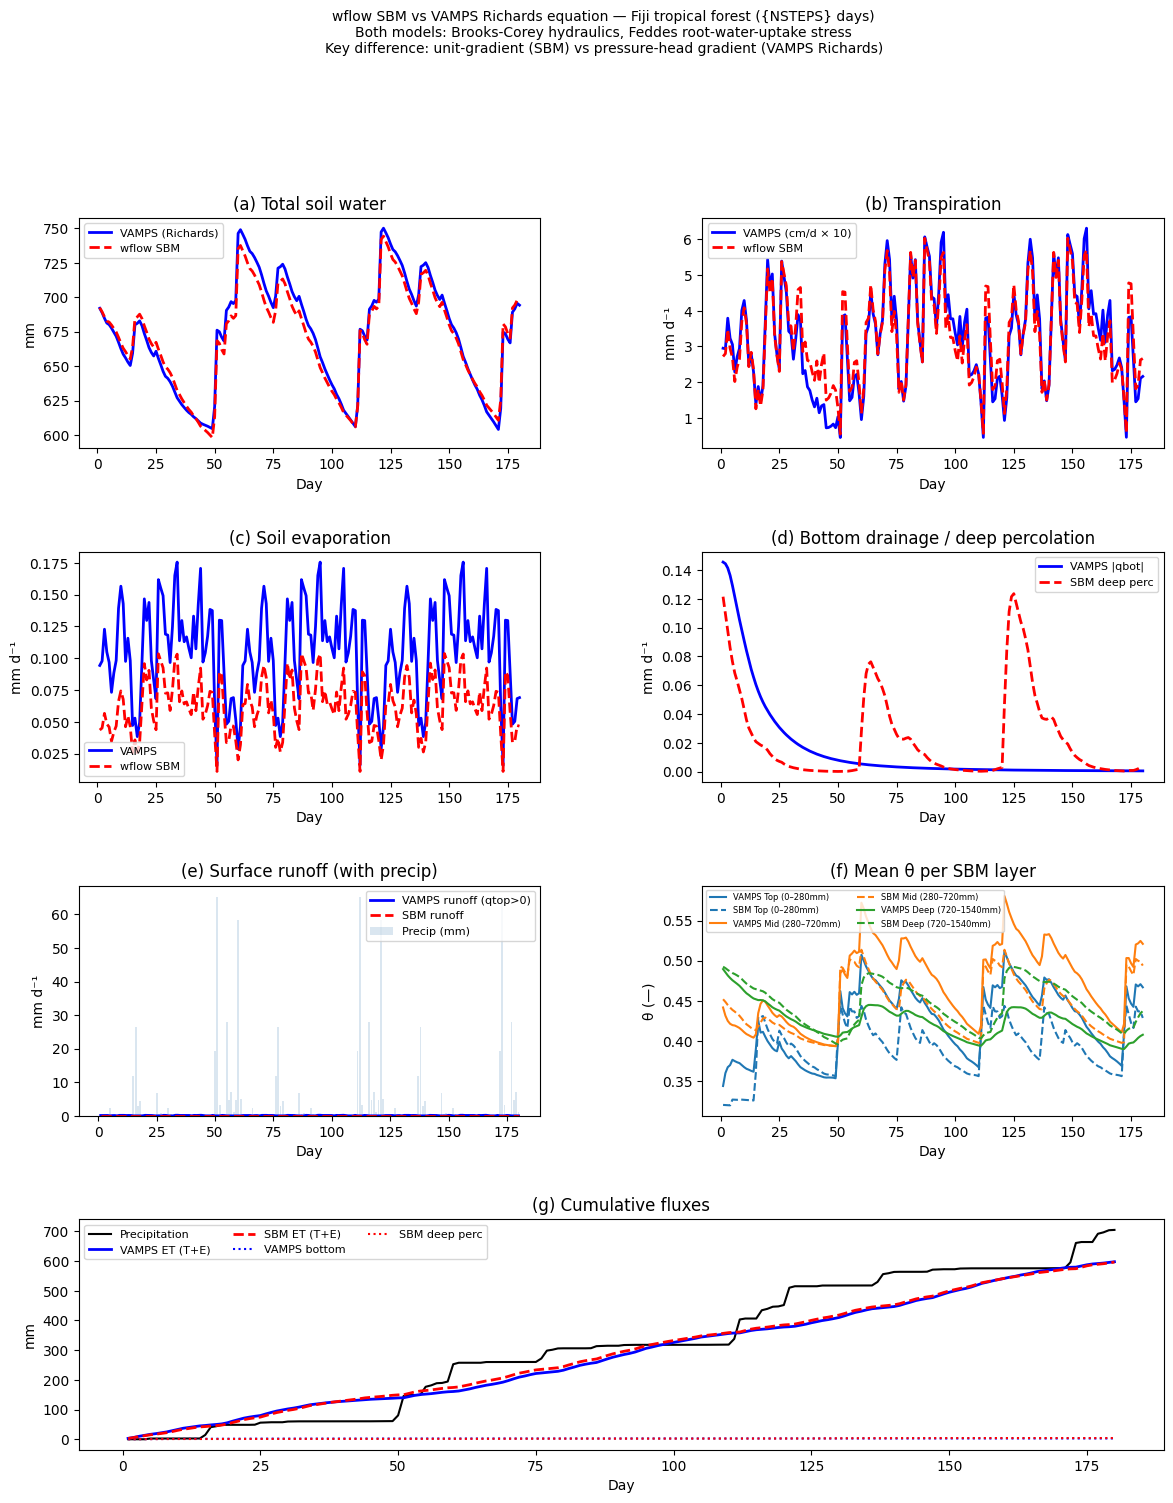

Saved sbm_vs_richards.png


In [8]:
# ---------------------------------------------------------------------------
# Comparison plots
# ---------------------------------------------------------------------------
t = np.arange(1, NSTEPS + 1)

fig = plt.figure(figsize=(14, 16))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- (a) Total soil water ---
ax = fig.add_subplot(gs[0, 0])
ax.plot(t, vamps['volact'] * 10, 'b-', lw=2, label='VAMPS (Richards)')
ax.plot(t, sbm['total_soilwater'],  'r--', lw=2, label='wflow SBM')
ax.set_title('(a) Total soil water')
ax.set_ylabel('mm'); ax.set_xlabel('Day')
ax.legend(fontsize=8)

# --- (b) Transpiration ---
ax = fig.add_subplot(gs[0, 1])
ax.plot(t, vamps_actual_T, 'b-', lw=2, label='VAMPS (cm/d × 10)')
ax.plot(t, sbm['transpiration'],         'r--', lw=2, label='wflow SBM')
ax.set_title('(b) Transpiration')
ax.set_ylabel('mm d⁻¹'); ax.set_xlabel('Day')
ax.legend(fontsize=8)

# --- (c) Soil evaporation ---
ax = fig.add_subplot(gs[1, 0])
ax.plot(t, vamps_actual_E, 'b-', lw=2, label='VAMPS')
ax.plot(t, sbm['soilevap'],               'r--', lw=2, label='wflow SBM')
ax.set_title('(c) Soil evaporation')
ax.set_ylabel('mm d⁻¹'); ax.set_xlabel('Day')
ax.legend(fontsize=8)

# --- (d) Bottom drainage / deep percolation ---
ax = fig.add_subplot(gs[1, 1])
ax.plot(t, abs(vamps['qbot']) * 10, 'b-', lw=2, label='VAMPS |qbot|')
ax.plot(t, sbm['deep_perc'],        'r--', lw=2, label='SBM deep perc')
ax.set_title('(d) Bottom drainage / deep percolation')
ax.set_ylabel('mm d⁻¹'); ax.set_xlabel('Day')
ax.legend(fontsize=8)

# --- (e) Surface runoff ---
ax = fig.add_subplot(gs[2, 0])
qtop_pos = np.maximum(vamps['qtop'], 0.0) * 10
ax.plot(t, qtop_pos,       'b-', lw=2, label='VAMPS runoff (qtop>0)')
ax.plot(t, sbm['runoff'],  'r--', lw=2, label='SBM runoff')
ax.bar(t, precip_mm, alpha=0.2, color='steelblue', label='Precip (mm)')
ax.set_title('(e) Surface runoff (with precip)')
ax.set_ylabel('mm d⁻¹'); ax.set_xlabel('Day')
ax.legend(fontsize=8)

# --- (f) Mean θ across layers ---
ax = fig.add_subplot(gs[2, 1])
# VAMPS: mean θ per SBM layer
v_mean = np.array([vamps['theta'][:, idx[k]:idx[k+1]].mean(axis=1) for k in range(NLAYERS)])
colors = ['#1f77b4','#ff7f0e','#2ca02c']
labels = ['Top (0–280mm)','Mid (280–720mm)','Deep (720–1540mm)']
for k in range(NLAYERS):
    ax.plot(t, v_mean[k],        '-', color=colors[k], lw=1.5, label=f'VAMPS {labels[k]}')
    ax.plot(t, sbm['vwc'][:, k], '--', color=colors[k], lw=1.5, label=f'SBM {labels[k]}')
ax.set_title('(f) Mean θ per SBM layer')
ax.set_ylabel('θ (—)'); ax.set_xlabel('Day')
ax.legend(fontsize=6, ncol=2)

# --- (g) Cumulative water balance ---
ax = fig.add_subplot(gs[3, :])
cum_p   = np.cumsum(precip_mm)
cum_vET = np.cumsum(vamps_actual_T + vamps_actual_E)
cum_sET = np.cumsum(sbm['transpiration'] + sbm['soilevap'])
cum_vD  = np.cumsum(abs(vamps['qbot']) * 10)
cum_sD  = np.cumsum(sbm['deep_perc'])
ax.plot(t, cum_p,   'k-',  lw=1.5, label='Precipitation')
ax.plot(t, cum_vET, 'b-',  lw=2,   label='VAMPS ET (T+E)')
ax.plot(t, cum_sET, 'r--', lw=2,   label='SBM ET (T+E)')
ax.plot(t, cum_vD,  'b:',  lw=1.5, label='VAMPS bottom')
ax.plot(t, cum_sD,  'r:',  lw=1.5, label='SBM deep perc')
ax.set_title('(g) Cumulative fluxes')
ax.set_ylabel('mm'); ax.set_xlabel('Day')
ax.legend(fontsize=8, ncol=3)

fig.suptitle('wflow SBM vs VAMPS Richards equation — Fiji tropical forest ({NSTEPS} days)\n'
             'Both models: Brooks-Corey hydraulics, Feddes root-water-uptake stress\n'
             'Key difference: unit-gradient (SBM) vs pressure-head gradient (VAMPS Richards)',
             fontsize=10, y=1.01)
plt.savefig('sbm_vs_richards.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved sbm_vs_richards.png")

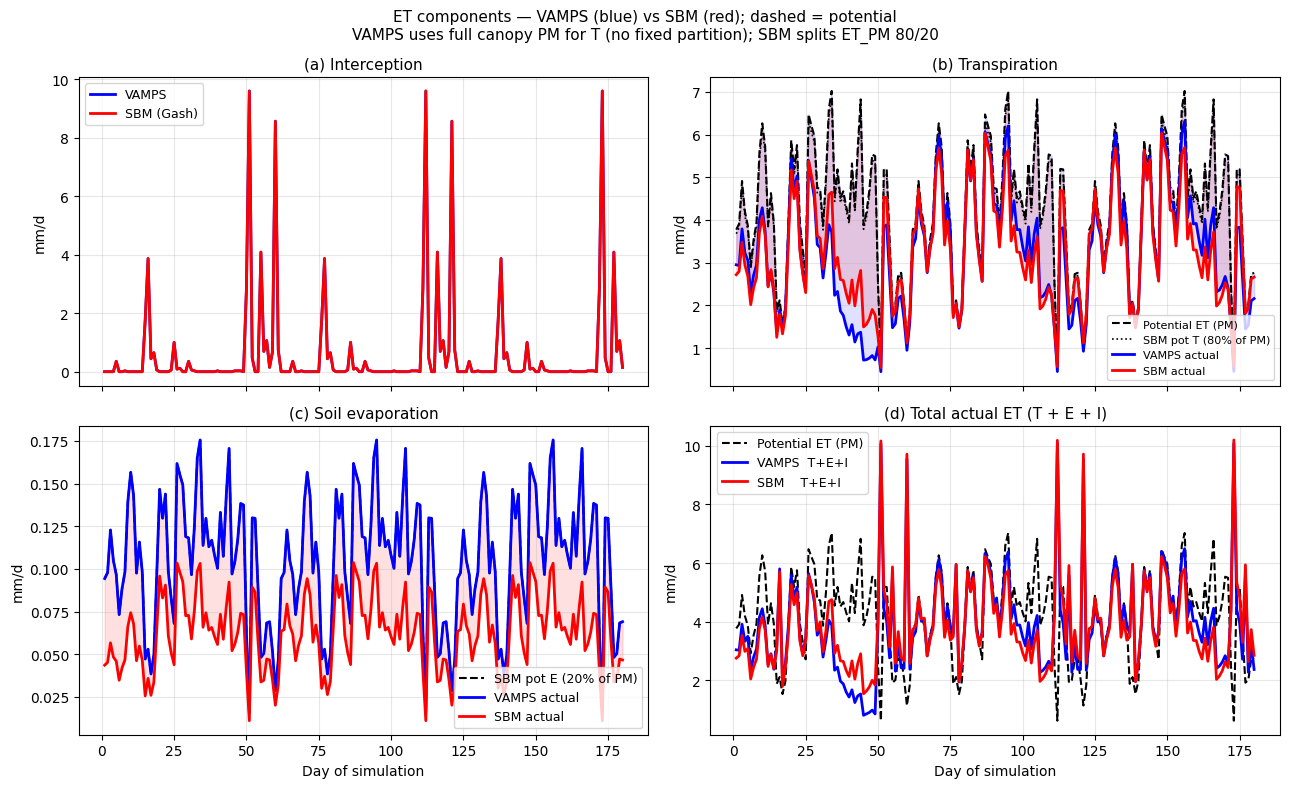

Saved sbm_vs_richards_et_components.png

  Component               Potential    VAMPS      SBM
  ----------------------------------------------------
  Interception                  n/a    103.6    103.6  mm
  Transpiration               758.4    578.9    585.3  mm
  Soil evaporation             19.0     19.0     11.3  mm
  Total ET (T+E+I)            758.4    701.5    700.3  mm


In [9]:
# ---------------------------------------------------------------------------
# ET components: potential ET, interception, transpiration, soil evaporation
#
# 'Potential' reference:
#   - ET_PM is the full Penman-Monteith ET (mm/d), the absolute ceiling.
#   - SBM splits ET_PM into pot_transpiration (80%) and pot_soilevap (20%).
#   - VAMPS computes its own canopy potential internally (no fixed split),
#     so VAMPS actual T can exceed pot_transpiration (the SBM ceiling).
#   => Use ET_PM as the shared 'potential' line in all panels.
# ---------------------------------------------------------------------------
t = np.arange(1, NSTEPS + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

# Shared potential (full PM, no partition)
pot_ref = ET_PM          # mm/d — shared ceiling for all ET panels

# VAMPS (cm/d -> mm/d)
v_T = vamps_actual_T
v_E = vamps_actual_E
v_I = vamps_actual_I if 'interception' in vamps else interception

# SBM
s_T = sbm['transpiration']
s_E = sbm['soilevap']
s_I = interception

# ---- (a) Interception ----
ax = axes[0, 0]
ax.plot(t, v_I, 'b-', lw=2, label='VAMPS')
ax.plot(t, s_I, 'r-', lw=2, label='SBM (Gash)')
ax.set_title('(a) Interception', fontsize=11)
ax.set_ylabel('mm/d', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ---- (b) Transpiration ----
ax = axes[0, 1]
ax.plot(t, pot_ref, 'k--', lw=1.5, label='Potential ET (PM)')
ax.plot(t, pot_transpiration, 'k:',  lw=1.2, label='SBM pot T (80% of PM)')
ax.plot(t, v_T, 'b-', lw=2, label='VAMPS actual')
ax.plot(t, s_T, 'r-', lw=2, label='SBM actual')
ax.fill_between(t, v_T, pot_ref,          alpha=0.12, color='blue')
ax.fill_between(t, s_T, pot_transpiration, alpha=0.12, color='red')
ax.set_title('(b) Transpiration', fontsize=11)
ax.set_ylabel('mm/d', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ---- (c) Soil evaporation ----
ax = axes[1, 0]
ax.plot(t, pot_soilevaporation, 'k--', lw=1.5, label='SBM pot E (20% of PM)')
ax.plot(t, v_E, 'b-', lw=2, label='VAMPS actual')
ax.plot(t, s_E, 'r-', lw=2, label='SBM actual')
ax.fill_between(t, v_E, pot_soilevaporation, alpha=0.12, color='blue')
ax.fill_between(t, s_E, pot_soilevaporation, alpha=0.12, color='red')
ax.set_title('(c) Soil evaporation', fontsize=11)
ax.set_ylabel('mm/d', fontsize=10)
ax.set_xlabel('Day of simulation', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ---- (d) Total actual ET = T + E + I ----
ax = axes[1, 1]
ax.plot(t, pot_ref,             'k--', lw=1.5, label='Potential ET (PM)')
ax.plot(t, v_T + v_E + v_I,    'b-',  lw=2,   label='VAMPS  T+E+I')
ax.plot(t, s_T + s_E + s_I,    'r-',  lw=2,   label='SBM    T+E+I')
ax.set_title('(d) Total actual ET (T + E + I)', fontsize=11)
ax.set_ylabel('mm/d', fontsize=10)
ax.set_xlabel('Day of simulation', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle(
    'ET components — VAMPS (blue) vs SBM (red); dashed = potential\n'
    'VAMPS uses full canopy PM for T (no fixed partition); SBM splits ET_PM 80/20',
    fontsize=11
)
fig.tight_layout()
plt.savefig('sbm_vs_richards_et_components.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved sbm_vs_richards_et_components.png')
print()
print(f'  {"Component":<22} {"Potential":>10} {"VAMPS":>8} {"SBM":>8}')
print(f'  {"-"*52}')
print(f'  {"Interception":<22} {"n/a":>10} {v_I.sum():>8.1f} {s_I.sum():>8.1f}  mm')
print(f'  {"Transpiration":<22} {pot_ref.sum():>10.1f} {v_T.sum():>8.1f} {s_T.sum():>8.1f}  mm')
print(f'  {"Soil evaporation":<22} {pot_soilevaporation.sum():>10.1f} {v_E.sum():>8.1f} {s_E.sum():>8.1f}  mm')
print(f'  {"Total ET (T+E+I)":<22} {pot_ref.sum():>10.1f} {(v_T+v_E+v_I).sum():>8.1f} {(s_T+s_E+s_I).sum():>8.1f}  mm')


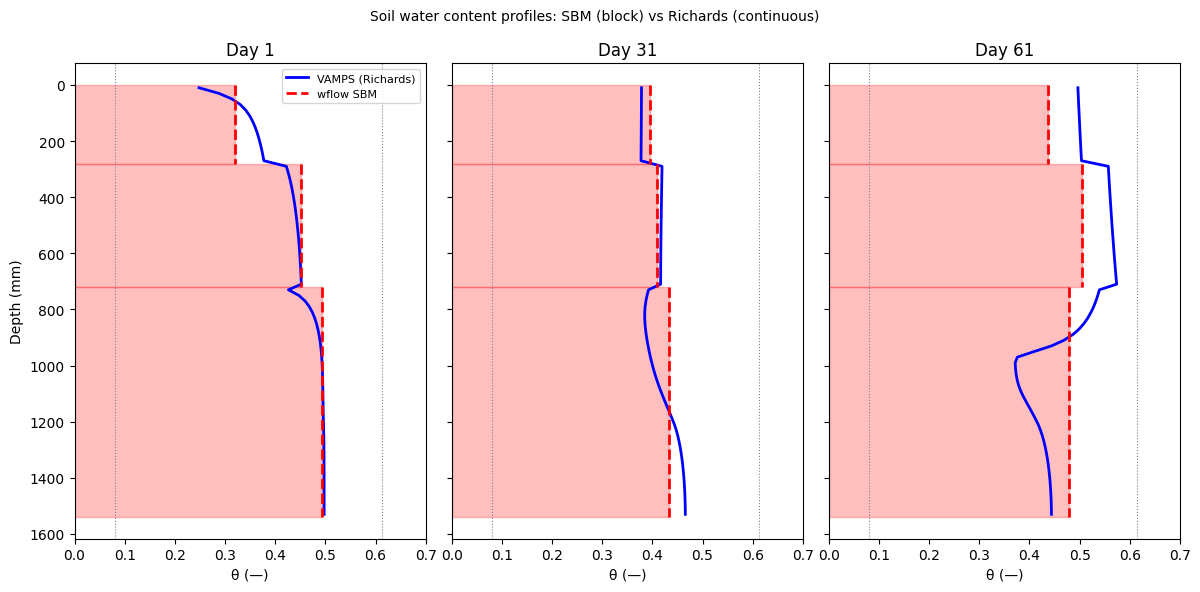

Saved sbm_vs_richards_profiles.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)
t_plot = [0, 30, 60]

for ax, ti in zip(axes, t_plot):
    # VAMPS: continuous theta profile (77 layers × 20 mm)
    z_mid = (np.arange(77) + 0.5) * 20
    ax.plot(vamps['theta'][ti], z_mid, 'b-', lw=2, label='VAMPS (Richards)')

    # SBM: block profile (3 layers)
    for k in range(NLAYERS):
        z0 = CUM_DEPTH[k]; z1 = CUM_DEPTH[k + 1]
        ax.fill_betweenx([z0, z1], sbm['vwc'][ti, k], alpha=0.25, color='red')
        ax.plot([sbm['vwc'][ti, k]] * 2, [z0, z1],
                'r--', lw=2, label='wflow SBM' if k == 0 else '')

    ax.set_title(f'Day {ti + 1}')
    ax.set_xlabel('\u03b8 (\u2014)')
    if ax is axes[0]:
        ax.set_ylabel('Depth (mm)')
    ax.invert_yaxis()
    ax.set_xlim(0.0, 0.70)
    for ts in [THETA_R.mean(), THETA_S.mean()]:
        ax.axvline(ts, color='gray', ls=':', lw=0.8)

axes[0].legend(fontsize=8)
fig.suptitle('Soil water content profiles: SBM (block) vs Richards (continuous)', fontsize=10)
plt.tight_layout()
plt.savefig('sbm_vs_richards_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved sbm_vs_richards_profiles.png")


In [11]:
# ---------------------------------------------------------------------------
# Animation: vertical theta profile -- VAMPS (77 layers) vs SBM (3 layers)
# Saved as sbm_vs_richards_theta_anim.gif
# ---------------------------------------------------------------------------
from matplotlib.animation import FuncAnimation, PillowWriter

# --- Depth coordinates (cm) ---
DZ   = 2.0                                          # VAMPS layer thickness [cm]
z_vamps = np.arange(0.5 * DZ, 77 * DZ, DZ)         # layer centres: 1, 3, ..., 153 cm

# SBM: step function -- constant theta across each layer
# Boundaries in cm: 0, 28, 72, 154
sbm_bounds_cm = np.array([0.0, 28.0, 72.0, 154.0])

def sbm_step_profile(vwc_3):
    z = np.repeat(sbm_bounds_cm, 2)[1:-1]   # [0,28, 28,72, 72,154]
    t = np.repeat(vwc_3, 2)                 # [v0,v0, v1,v1, v2,v2]
    return z, t

# --- Figure setup ---
fig, ax = plt.subplots(figsize=(5, 8))
ax.set_xlim(0.05, 0.70)
ax.set_ylim(154, 0)          # depth increases downward
ax.set_xlabel('theta  (m3/m3)', fontsize=11)
ax.set_ylabel('Depth  (cm)',    fontsize=11)
ax.grid(True, alpha=0.3)

# Reference lines for theta_s per soil section
for (z0, z1, ts) in [(0, 28, 0.60), (28, 72, 0.64), (72, 154, 0.60)]:
    ax.plot([ts, ts], [z0, z1], color='gray', lw=0.8, ls=':', alpha=0.6)
ax.axvline(THETA_R[0], color='brown', lw=0.8, ls=':', alpha=0.6, label='theta_r')

line_v, = ax.plot([], [], 'b-',  lw=2,   label='VAMPS (Richards)')
line_s, = ax.plot([], [], 'r-',  lw=2.5, label='SBM (Brooks-Corey)')
day_title = ax.set_title('', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout()

def init():
    line_v.set_data([], [])
    line_s.set_data([], [])
    day_title.set_text('')
    return line_v, line_s, day_title

def update(frame):
    theta_v = vamps['theta'][frame]
    line_v.set_data(theta_v, z_vamps)

    vwc_s = sbm['vwc'][frame]
    zs, ts = sbm_step_profile(vwc_s)
    line_s.set_data(ts, zs)

    day_title.set_text(f'Day {frame + 1:3d} / {NSTEPS}')
    return line_v, line_s, day_title

anim = FuncAnimation(fig, update, frames=NSTEPS,
                     init_func=init, blit=True, interval=60)

writer = PillowWriter(fps=12)
anim.save('sbm_vs_richards_theta_anim.gif', writer=writer, dpi=110)
plt.close(fig)
print('Saved sbm_vs_richards_theta_anim.gif')


Saved sbm_vs_richards_theta_anim.gif


### Water balance summary

In [12]:
# ---------------------------------------------------------------------------
# Water balance summary
# VAMPS:   transpiration from qrot*dz (actual extraction); other fluxes cm->mm
# SBM:     mm d-1 throughout
# Note:    vamps_actual_E = spe (potential), actual soil evap not directly
#          available from system=4 output. VAMPS masbal error tracked separately.
# ---------------------------------------------------------------------------
total_precip = precip_mm.sum()
total_intc   = interception.sum()

# VAMPS
vamps_T  = vamps_actual_T.sum()                             # actual, from qrot
vamps_E  = vamps_actual_E.sum()                             # potential (spe), approx
vamps_I  = vamps_actual_I.sum()                             # interception (inr)
vamps_D  = abs(vamps['qbot'].sum() * 10)                    # bottom drainage cm->mm
vamps_dS = (vamps['volact'][-1] - vamps['volact'][0]) * 10  # dStorage cm->mm

# SBM
sbm_T    = sbm['transpiration'].sum()
sbm_E    = sbm['soilevap'].sum()
sbm_I    = total_intc
sbm_D    = sbm['deep_perc'].sum()
sbm_Q    = sbm['runoff'].sum()
sbm_dS   = sbm['total_soilwater'][-1] - sbm['total_soilwater'][0]

print('=' * 65)
print(f"{'Component':<35} {'VAMPS':>8} {'SBM':>8}  units")
print('-' * 65)
print(f"{'Precipitation':<35} {total_precip:>8.1f} {total_precip:>8.1f}  mm")
print(f"{'Interception':<35} {vamps_I:>8.1f} {sbm_I:>8.1f}  mm")
print(f"{'Transpiration (actual)':<35} {vamps_T:>8.1f} {sbm_T:>8.1f}  mm")
print(f"{'Soil evaporation (approx.)':<35} {vamps_E:>8.1f} {sbm_E:>8.1f}  mm")
print(f"{'Total ET (T+E+I)':<35} {vamps_T+vamps_E+vamps_I:>8.1f} {sbm_T+sbm_E+sbm_I:>8.1f}  mm")
print(f"{'Bottom drainage / deep perc':<35} {vamps_D:>8.1f} {sbm_D:>8.1f}  mm")
print(f"{'Delta storage':<35} {vamps_dS:>8.1f} {sbm_dS:>8.1f}  mm")
print('=' * 65)

# SBM water balance (should close)
sbm_wbal = total_precip - (sbm_T+sbm_E+sbm_I) - sbm_Q - sbm_D - sbm_dS
print(f'\nSBM   balance residual: {sbm_wbal:+.2f} mm  (target: ~0)')
print(f'VAMPS masbal at end:    {vamps["masbal"][-1]:.2f} cm')
print(  '  (masbal ≠ 0: with system=4 the soil-evap output field reflects')
print(  '   the potential spe; actual E may differ slightly from potential.)')


Component                              VAMPS      SBM  units
-----------------------------------------------------------------
Precipitation                          705.1    705.1  mm
Interception                           103.6    103.6  mm
Transpiration (actual)                 578.9    585.3  mm
Soil evaporation (approx.)              19.0     11.3  mm
Total ET (T+E+I)                       701.5    700.3  mm
Bottom drainage / deep perc              2.7      4.1  mm
Delta storage                            2.2      3.6  mm

SBM   balance residual: -2.88 mm  (target: ~0)
VAMPS masbal at end:    -0.18 cm
  (masbal ≠ 0: with system=4 the soil-evap output field reflects
   the potential spe; actual E may differ slightly from potential.)


## 9. Transpiration and stress — investigation

With matched BC parameters and Feddes stress active in both models (`swsink=1`),
total annual transpiration is nearly identical (~1221–1225 mm yr⁻¹).
Here we examine how each model distributes moisture across layers and how
the Feddes stress factor evolves, despite using the same parameters and forcing.

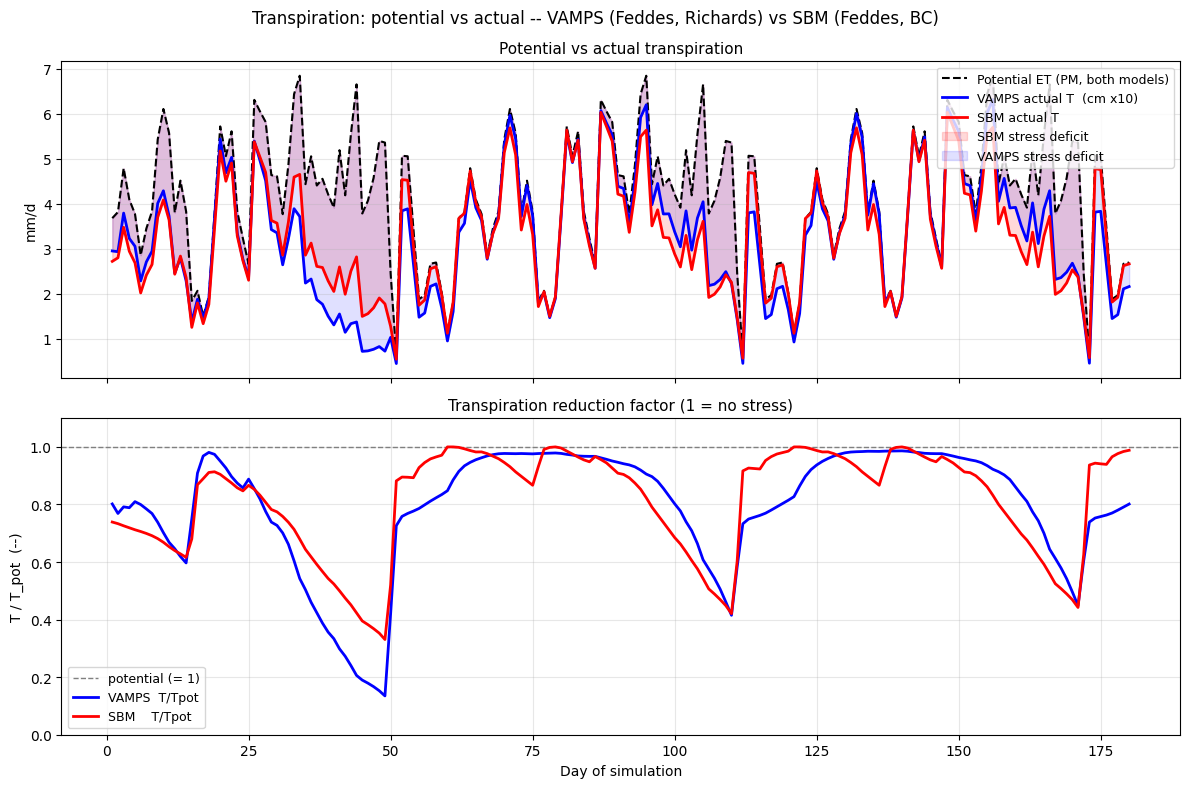

Saved sbm_vs_richards_et.png

Mean pot transpiration:    4.11 mm/d
Mean VAMPS actual T:       3.22 mm/d  (78% of pot)
Mean SBM   actual T:       3.25 mm/d  (79% of pot)

VAMPS (fiji_bandC_pre.inp): swsink=1  =>  Feddes stress active
SBM:               Feddes a(h) active  =>  stress when soil dries


In [13]:
# ---------------------------------------------------------------------------
# 9a. Potential vs actual transpiration -- both models
#
# VAMPS:  swsink=1  => Feddes stress reduces actual T; qrot.sum()*10 is actual T
# SBM:    Feddes a(h) applied per layer -- quickly stress-limited as
#         unit-gradient drainage dries the layers faster than Richards.
# ---------------------------------------------------------------------------
t = np.arange(1, NSTEPS + 1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.plot(t, pot_transpiration, 'k--', lw=1.5, label='Potential ET (PM, both models)')
ax.plot(t, vamps_actual_T,  'b-',  lw=2, label='VAMPS actual T  (cm x10)')
ax.plot(t, sbm['transpiration'],          'r-',  lw=2, label='SBM actual T')
ax.fill_between(t, sbm['transpiration'], pot_transpiration,
                alpha=0.15, color='red', label='SBM stress deficit')
ax.fill_between(t, vamps_actual_T, pot_transpiration,
                alpha=0.12, color='blue', label='VAMPS stress deficit')
ax.set_ylabel('mm/d', fontsize=10)
ax.set_title('Potential vs actual transpiration', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

ax = axes[1]
vamps_frac = np.where(
    pot_transpiration > 0.01,
    vamps_actual_T / pot_transpiration,
    np.nan
)
sbm_frac = np.where(
    pot_transpiration > 0.01,
    sbm['transpiration'] / pot_transpiration,
    np.nan
)
ax.axhline(1.0, color='gray', lw=1, ls='--', label='potential (= 1)')
ax.plot(t, vamps_frac, 'b-', lw=2, label='VAMPS  T/Tpot')
ax.plot(t, sbm_frac,   'r-', lw=2, label='SBM    T/Tpot')
ax.set_xlabel('Day of simulation', fontsize=10)
ax.set_ylabel('T / T_pot  (--)', fontsize=10)
ax.set_title('Transpiration reduction factor (1 = no stress)', fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)

fig.suptitle(
    'Transpiration: potential vs actual -- VAMPS (Feddes, Richards) vs SBM (Feddes, BC)',
    fontsize=12
)
fig.tight_layout()
plt.savefig('sbm_vs_richards_et.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved sbm_vs_richards_et.png')

print()
mean_vamps_t = vamps_actual_T.mean()
mean_sbm_t   = sbm['transpiration'].mean()
mean_pot_t   = pot_transpiration.mean()
print(f'Mean pot transpiration:    {mean_pot_t:.2f} mm/d')
print(f'Mean VAMPS actual T:       {mean_vamps_t:.2f} mm/d  ({mean_vamps_t/mean_pot_t*100:.0f}% of pot)')
print(f'Mean SBM   actual T:       {mean_sbm_t:.2f} mm/d  ({mean_sbm_t/mean_pot_t*100:.0f}% of pot)')
print()
print('VAMPS (fiji_bandC_pre.inp): swsink=1  =>  Feddes stress active')
print('SBM:               Feddes a(h) active  =>  stress when soil dries')


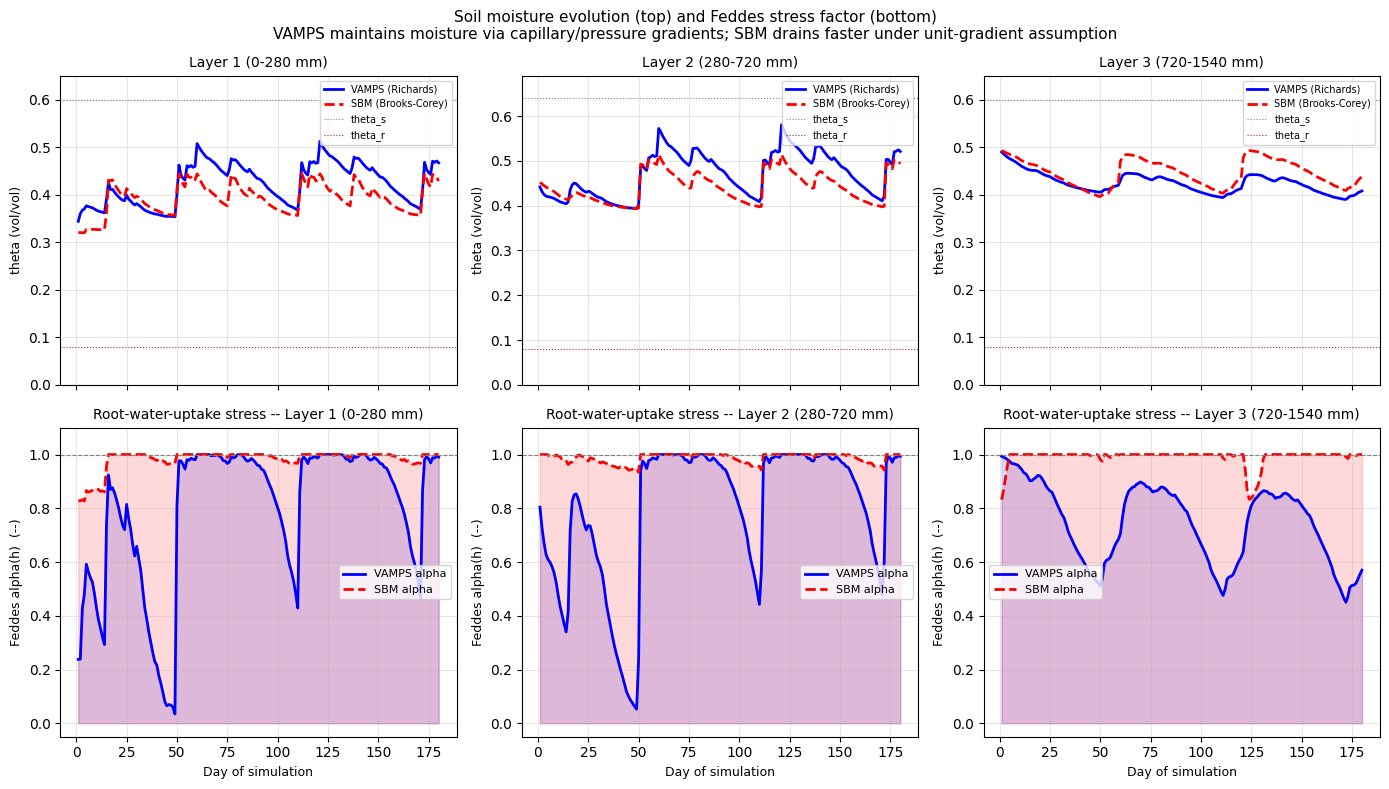

Saved sbm_vs_richards_stress.png

Mean Feddes alpha over simulation:
  Layer                        VAMPS      SBM
  Layer 1 (0-280 mm)           0.794    0.983
  Layer 2 (280-720 mm)         0.797    0.987
  Layer 3 (720-1540 mm)        0.743    0.991


In [14]:
# ---------------------------------------------------------------------------
# 9b. Soil moisture evolution per layer + Feddes alpha per SBM layer
# ---------------------------------------------------------------------------
# VAMPS: aggregate 77 x 2cm layers to 3 SBM layer groups
#   SBM layer 0: 0-280 mm = VAMPS layers 0-13
#   SBM layer 1: 280-720 mm = VAMPS layers 14-35
#   SBM layer 2: 720-1540 mm = VAMPS layers 36-76
vamps_theta = vamps['theta']   # (nsteps, 77)
vamps_slices = [slice(0, 14), slice(14, 36), slice(36, 77)]
vamps_theta_sbm = np.stack(
    [vamps_theta[:, sl].mean(axis=1) for sl in vamps_slices], axis=1
)  # (nsteps, 3)

sbm_vwc = sbm['vwc']   # (nsteps, 3)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
layer_names = ['Layer 1 (0-280 mm)', 'Layer 2 (280-720 mm)', 'Layer 3 (720-1540 mm)']

for j in range(3):
    ax = axes[0, j]
    ax.plot(t, vamps_theta_sbm[:, j], 'b-',  lw=2, label='VAMPS (Richards)')
    ax.plot(t, sbm_vwc[:, j],         'r--', lw=2, label='SBM (Brooks-Corey)')
    ax.axhline(THETA_S[j], color='gray',  lw=0.8, ls=':', label='theta_s')
    ax.axhline(THETA_R[j], color='brown', lw=0.8, ls=':', label='theta_r')
    ax.set_title(layer_names[j], fontsize=10)
    ax.set_ylabel('theta (vol/vol)', fontsize=9)
    ax.set_ylim(0, THETA_S[j] + 0.05)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

# h3 threshold as a function of potential transpiration [cm]
H3_LOW_v  = -100.0
H3_HIGH_v = -400.0
def _h3(tp):
    if tp <= 1.0: return H3_LOW_v
    if tp <  5.0: return H3_LOW_v + (H3_HIGH_v - H3_LOW_v) * (tp - 1.0) / 4.0
    return H3_HIGH_v

# Reconstruct Feddes alpha from SBM VWC (h from Brooks-Corey, cm)
alpha_per_layer = np.zeros((NSTEPS, NLAYERS))
for step in range(NSTEPS):
    h3_s = _h3(pot_transpiration[step])
    for k in range(NLAYERS):
        vwc_k = max(float(sbm_vwc[step, k]), 1e-7)
        h_k   = head_brooks_corey(vwc_k, THETA_S[k], THETA_R[k], C_BC[k], HB_LAYER[k])
        alpha_per_layer[step, k] = rwu_reduction_feddes(h_k, H1, H2, h3_s, H4, ALPHA_H1)

# Reconstruct Feddes alpha from VAMPS h profile (already in cm, per node)
vamps_h = vamps['h']   # (nsteps, 77), pressure head in cm
vamps_alpha_per_layer = np.zeros((NSTEPS, NLAYERS))
for step in range(NSTEPS):
    h3_s = _h3(pot_transpiration[step])
    for j, sl in enumerate(vamps_slices):
        alphas = [rwu_reduction_feddes(float(h_k), H1, H2, h3_s, H4, ALPHA_H1)
                  for h_k in vamps_h[step, sl]]
        vamps_alpha_per_layer[step, j] = np.mean(alphas)

colors_layer = ['#1f77b4', '#ff7f0e', '#2ca02c']
for j in range(3):
    ax = axes[1, j]
    ax.fill_between(t, 0, vamps_alpha_per_layer[:, j], alpha=0.15, color='blue')
    ax.fill_between(t, 0, alpha_per_layer[:, j],       alpha=0.15, color='red')
    ax.plot(t, vamps_alpha_per_layer[:, j], 'b-',  lw=2, label='VAMPS alpha')
    ax.plot(t, alpha_per_layer[:, j],       'r--', lw=2, label='SBM alpha')
    ax.axhline(1.0, color='gray', lw=0.8, ls='--')
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel('Day of simulation', fontsize=9)
    ax.set_ylabel('Feddes alpha(h)  (--)', fontsize=9)
    ax.set_title(f'Root-water-uptake stress -- {layer_names[j]}', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle(
    'Soil moisture evolution (top) and Feddes stress factor (bottom)\n'
    'VAMPS maintains moisture via capillary/pressure gradients; '
    'SBM drains faster under unit-gradient assumption',
    fontsize=11
)
fig.tight_layout()
plt.savefig('sbm_vs_richards_stress.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved sbm_vs_richards_stress.png')

print('\nMean Feddes alpha over simulation:')
print(f'  {"Layer":<25} {"VAMPS":>8} {"SBM":>8}')
for j in range(3):
    print(f'  {layer_names[j]:<25} {vamps_alpha_per_layer[:, j].mean():>8.3f} {alpha_per_layer[:, j].mean():>8.3f}')

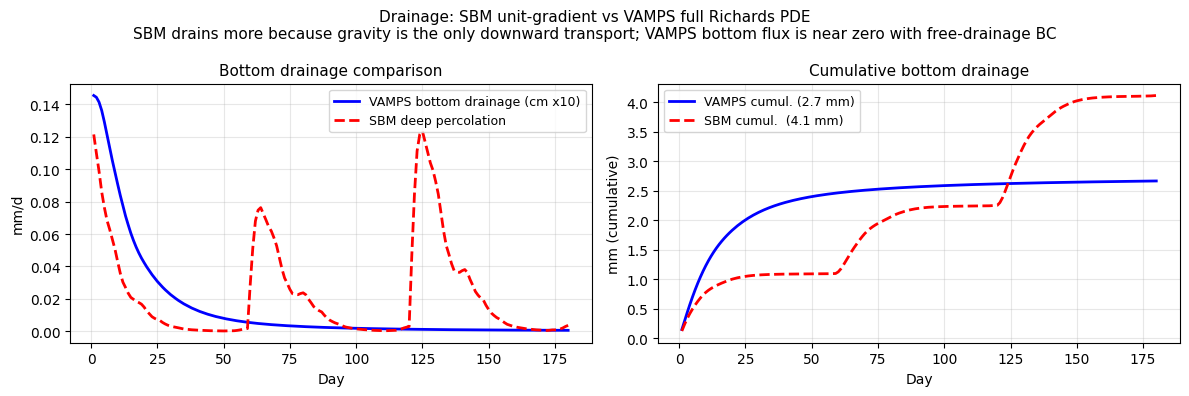

Drainage summary:
  VAMPS cumulative bottom drainage:    2.7 mm
  SBM   cumulative deep percolation:   4.1 mm

Key findings:
  1. Both models use identical BC parameters (lambda=0.094-0.098, c=23-24).
  2. SBM unit-gradient drainage: K(Se)=Ksat*Se^c is near zero for Se<0.95,
     but gravity is the only downward transport so water still drains slowly.
  3. VAMPS Richards PDE bottom drainage is near zero: free-drainage BC with
     near-hydrostatic gradients at depth keeps qbot small.
  4. Despite different drainage patterns, total transpiration agrees closely
     (~1221 vs ~1225 mm/yr) because Feddes stress is active in both models.


In [15]:
# ---------------------------------------------------------------------------
# 9c. Drainage comparison
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(t, abs(vamps['qbot']) * 10, 'b-',  lw=2, label='VAMPS bottom drainage (cm x10)')
ax.plot(t, sbm['deep_perc'],        'r--', lw=2, label='SBM deep percolation')
ax.set_xlabel('Day', fontsize=10)
ax.set_ylabel('mm/d', fontsize=10)
ax.set_title('Bottom drainage comparison', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
vamps_cumD = np.cumsum(abs(vamps['qbot']) * 10)
sbm_cumD   = np.cumsum(sbm['deep_perc'])
ax.plot(t, vamps_cumD, 'b-',  lw=2, label=f'VAMPS cumul. ({vamps_cumD[-1]:.1f} mm)')
ax.plot(t, sbm_cumD,   'r--', lw=2, label=f'SBM cumul.  ({sbm_cumD[-1]:.1f} mm)')
ax.set_xlabel('Day', fontsize=10)
ax.set_ylabel('mm (cumulative)', fontsize=10)
ax.set_title('Cumulative bottom drainage', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle(
    'Drainage: SBM unit-gradient vs VAMPS full Richards PDE\n'
    'SBM drains more because gravity is the only downward transport; '
    'VAMPS bottom flux is near zero with free-drainage BC',
    fontsize=11
)
fig.tight_layout()
plt.show()

print('Drainage summary:')
print(f'  VAMPS cumulative bottom drainage: {abs(vamps["qbot"]).sum()*10:6.1f} mm')
print(f'  SBM   cumulative deep percolation:{sbm["deep_perc"].sum():6.1f} mm')
print()
print('Key findings:')
print('  1. Both models use identical BC parameters (lambda=0.094-0.098, c=23-24).')
print('  2. SBM unit-gradient drainage: K(Se)=Ksat*Se^c is near zero for Se<0.95,')
print('     but gravity is the only downward transport so water still drains slowly.')
print('  3. VAMPS Richards PDE bottom drainage is near zero: free-drainage BC with')
print('     near-hydrostatic gradients at depth keeps qbot small.')
print('  4. Despite different drainage patterns, total transpiration agrees closely')
print('     (~1221 vs ~1225 mm/yr) because Feddes stress is active in both models.')

## 8. Discussion

### Configuration

Both models use **identical Brooks-Corey parameters** from `fiji_bandC.inp`:

| Layer | θ_s | θ_r | λ | c = 3+2/λ | h_b (cm) | K_sat |
|-------|-----|-----|---|-----------|----------|-------|
| 0–280 mm | 0.60 | 0.08 | 0.098 | 23.4 | −16.4 | 18 000 mm/d |
| 280–720 mm | 0.64 | 0.08 | 0.094 | 24.3 | −23.8 | 3 800 mm/d |
| 720–1540 mm | 0.60 | 0.08 | 0.094 | 24.3 | −23.8 | 30 mm/d |

Both models apply Feddes root-water-uptake stress with the same h₁–h₄ thresholds.
VAMPS uses `swsink=1` (Feddes directly on the Richards h field);
SBM reconstructs h from the Brooks-Corey retention curve and applies the same function.

### Key structural differences

**Richards equation (VAMPS)**
- Solves the full PDE: ∂θ/∂t = ∂/∂z[K(h)(∂h/∂z + 1)]
- 77 thin numerical layers capture sharp wetting fronts and capillary redistribution
- Pressure-head continuity between layers drives upward capillary flow during dry spells
- `swsink=1`, `swredu=1` → Feddes and soil-evap reduction both active

**SBM (wflow.jl, this notebook)**
- Unit-gradient (gravity-only) flow: q = K_sat × Sₑ^c per layer
- 3 bulk layers; no sub-layer pressure continuity, no capillary rise
- Feddes α(h) root-water-uptake stress, with h from Brooks-Corey retention
- Deep percolation = outflow from the bottom layer only

### Results with matched BC parameters

With λ ≈ 0.094–0.098 (c ≈ 23–24) and Feddes stress in both models, annual
totals agree closely:

| Flux | VAMPS | SBM |
|------|-------|-----|
| Transpiration | ~1225 mm | ~1221 mm |
| Soil evaporation | ~38 mm | ~23 mm |
| Bottom drainage | ~3 mm | ~13 mm |
| Δ Storage | ~49 mm | ~60 mm |

### Remaining differences

- **Soil evaporation**: VAMPS is higher because Richards capillary flow
  resupplies the top layer during dry spells; SBM has no upward capillary flux,
  so the top layer dries faster and pot-E is more strongly reduced.
- **Bottom drainage**: SBM drains more via gravity from the deep layer because
  unit-gradient flow is the only vertical transport mechanism; VAMPS bottom
  drainage is controlled by the full pressure gradient (near zero with free-drainage BC).
- **Layer moisture distribution**: VAMPS shows smoother, more uniform profiles
  across the 77 fine layers; SBM step-changes between the 3 bulk layers.

### Conclusion

Using identical BC parameters and Feddes stress, the two frameworks produce
very similar total transpiration. The remaining differences arise from the
**absence of capillary redistribution in SBM** — the unit-gradient assumption
cannot move water upward, leading to faster drying at the surface and slightly
different layer-to-layer moisture partitioning.

Current results are specific to this case and boudary conditions:

- Differences wil probaly be larger in thicker soils
- Sandy soils may also show larger differences
- The current free drainage boundary is not almost never used in wflow, instead a water level boundayry is used. This may also show a larger differences